# 06 — Statistical Plots
**Goal:** Visualize uncertainty, distributions, and relationships with statistical rigor.

Topics:
- Error bars
- Confidence intervals
- Regression line with confidence band
- KDE (smooth distribution)
- Heatmap / correlation matrix
- QQ plot

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

plt.rcParams.update({
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size':         11,
})

df = pd.read_csv('data/raw/funnel_data.csv', parse_dates=['date'])
np.random.seed(42)
print('Ready')

Ready


## 1. Error bars — showing uncertainty around a mean

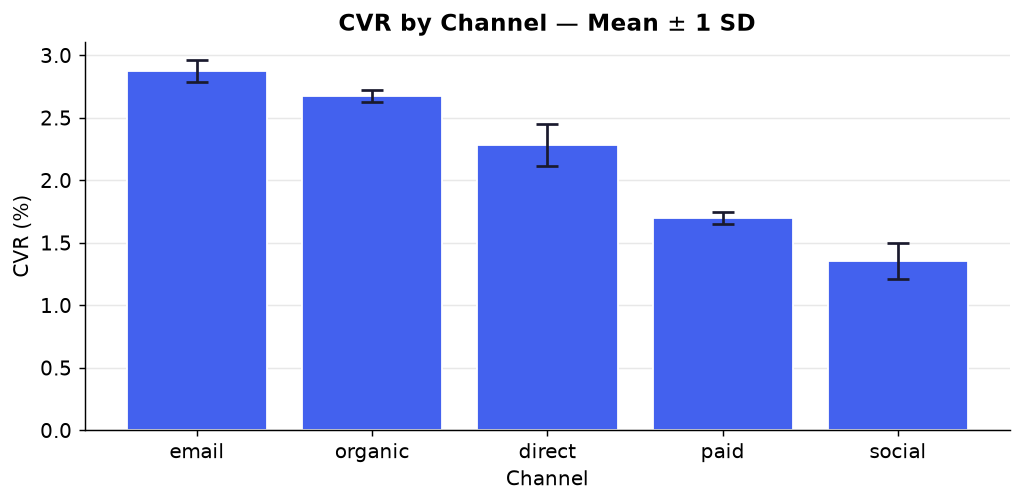

In [2]:
# CVR per channel: mean and standard deviation across days
channel_stats = df.groupby('channel').apply(
    lambda g: pd.Series({
        'mean_cvr': (g['activacion_tarjeta'] / g['visita_landing'] * 100).mean(),
        'std_cvr':  (g['activacion_tarjeta'] / g['visita_landing'] * 100).std(),
    })
).reset_index().sort_values('mean_cvr', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4), dpi=130)

# yerr = error bar size (here: ±1 std dev)
# capsize = width of the horizontal cap on the error bar
ax.bar(channel_stats['channel'], channel_stats['mean_cvr'],
       yerr=channel_stats['std_cvr'],
       capsize=6,
       color='#4361ee', edgecolor='white',
       error_kw=dict(ecolor='#1a1a2e', elinewidth=1.5, capthick=1.5))

ax.set_title(r'CVR by Channel — Mean $\pm$ 1 SD', fontsize=13, fontweight='bold')
ax.set_ylabel('CVR (%)')
ax.set_xlabel('Channel')
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 2. Confidence interval band on a time series

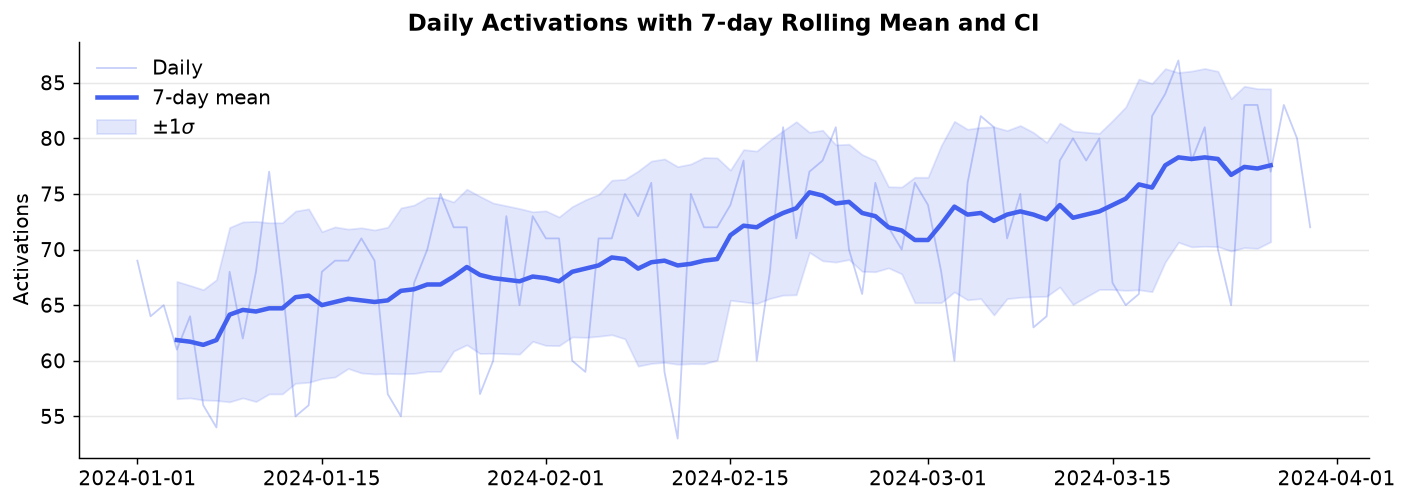

In [3]:
# Rolling 7-day mean and standard deviation
daily = df.groupby('date')['activacion_tarjeta'].sum().reset_index()
daily['roll_mean'] = daily['activacion_tarjeta'].rolling(7, center=True).mean()
daily['roll_std']  = daily['activacion_tarjeta'].rolling(7, center=True).std()

fig, ax = plt.subplots(figsize=(11, 4), dpi=130)

# Raw data — faint
ax.plot(daily['date'], daily['activacion_tarjeta'],
        color='#4361ee', alpha=0.3, linewidth=1, label='Daily')

# Rolling mean — bold
ax.plot(daily['date'], daily['roll_mean'],
        color='#4361ee', linewidth=2.5, label='7-day mean')

# Confidence band: mean ± 1 std dev
# fill_between fills the area between two y arrays
ax.fill_between(daily['date'],
                daily['roll_mean'] - daily['roll_std'],
                daily['roll_mean'] + daily['roll_std'],
                alpha=0.15, color='#4361ee', label=r'$\pm 1\sigma$')

ax.set_title('Daily Activations with 7-day Rolling Mean and CI', fontsize=13, fontweight='bold')
ax.set_ylabel('Activations')
ax.legend(frameon=False)
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 3. Scatter with regression line and confidence band

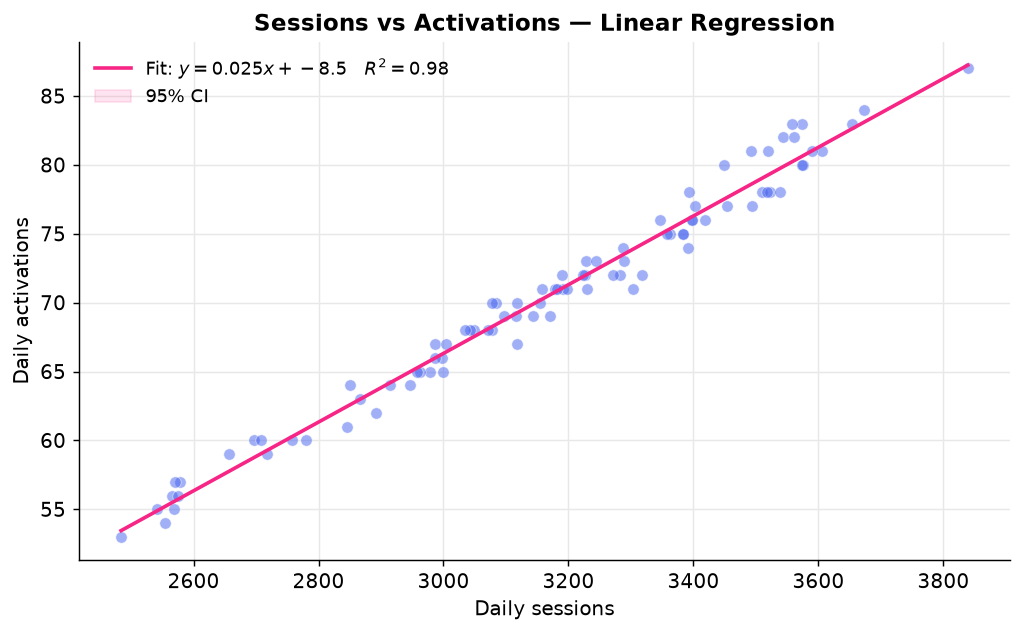

In [4]:
daily_agg = df.groupby('date').agg(
    sessions=('visita_landing', 'sum'),
    activations=('activacion_tarjeta', 'sum')
).reset_index()

x = daily_agg['sessions'].values
y = daily_agg['activations'].values

# Linear regression using scipy
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

x_line = np.linspace(x.min(), x.max(), 200)
y_line = slope * x_line + intercept

# Confidence band: ±1.96 * standard error of the regression
n = len(x)
x_mean = x.mean()
se_band = std_err * np.sqrt(1/n + (x_line - x_mean)**2 / np.sum((x - x_mean)**2))
ci = 1.96 * se_band   # 95% confidence interval

fig, ax = plt.subplots(figsize=(8, 5), dpi=130)

ax.scatter(x, y, color='#4361ee', alpha=0.5, s=40, edgecolors='white', linewidth=0.5)

# Regression line
ax.plot(x_line, y_line, color='#f72585', linewidth=2,
        label=fr'Fit: $y = {slope:.3f}x + {intercept:.1f}$   $R^2={r_value**2:.2f}$')

# 95% CI band
ax.fill_between(x_line, y_line - ci, y_line + ci,
                alpha=0.12, color='#f72585', label='95% CI')

ax.set_title('Sessions vs Activations — Linear Regression', fontsize=13, fontweight='bold')
ax.set_xlabel('Daily sessions')
ax.set_ylabel('Daily activations')
ax.legend(frameon=False, fontsize=10)
ax.grid(color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 4. KDE — smooth distribution curve
KDE (Kernel Density Estimation) is a smoothed version of a histogram.

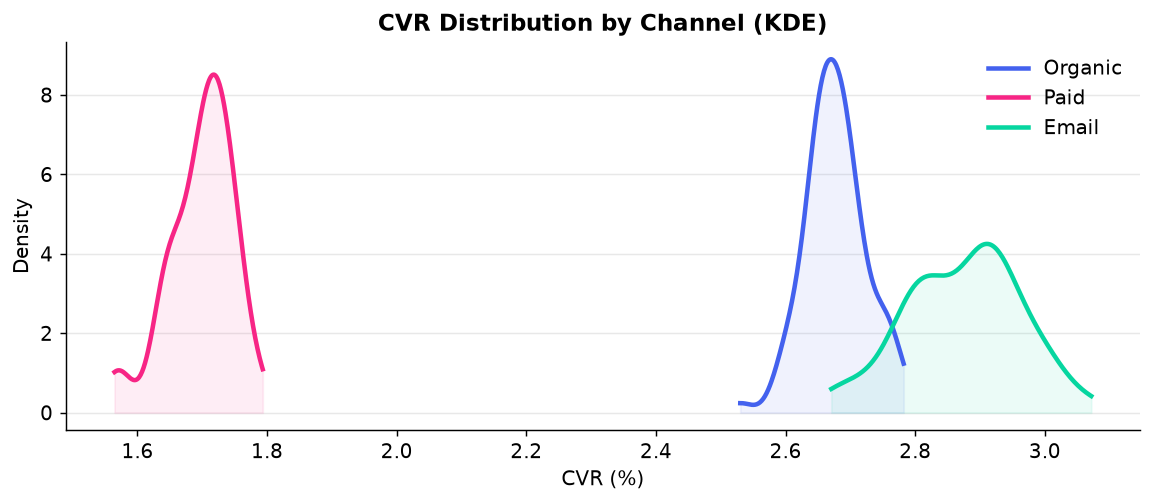

In [5]:
channels_to_compare = ['organic', 'paid', 'email']
colors = ['#4361ee', '#f72585', '#06d6a0']

fig, ax = plt.subplots(figsize=(9, 4), dpi=130)

for ch, color in zip(channels_to_compare, colors):
    cvr_vals = (df[df['channel'] == ch]['activacion_tarjeta'] /
                df[df['channel'] == ch]['visita_landing'] * 100).dropna()

    # Compute KDE using scipy
    kde = stats.gaussian_kde(cvr_vals)
    x_range = np.linspace(cvr_vals.min(), cvr_vals.max(), 200)

    # Plot the smooth curve
    ax.plot(x_range, kde(x_range), color=color, linewidth=2.5, label=ch.capitalize())

    # Fill under the curve for visual weight
    ax.fill_between(x_range, kde(x_range), alpha=0.08, color=color)

ax.set_title('CVR Distribution by Channel (KDE)', fontsize=13, fontweight='bold')
ax.set_xlabel('CVR (%)')
ax.set_ylabel('Density')
ax.legend(frameon=False)
ax.grid(axis='y', color='#e8e8e8', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## 5. Heatmap — correlation matrix

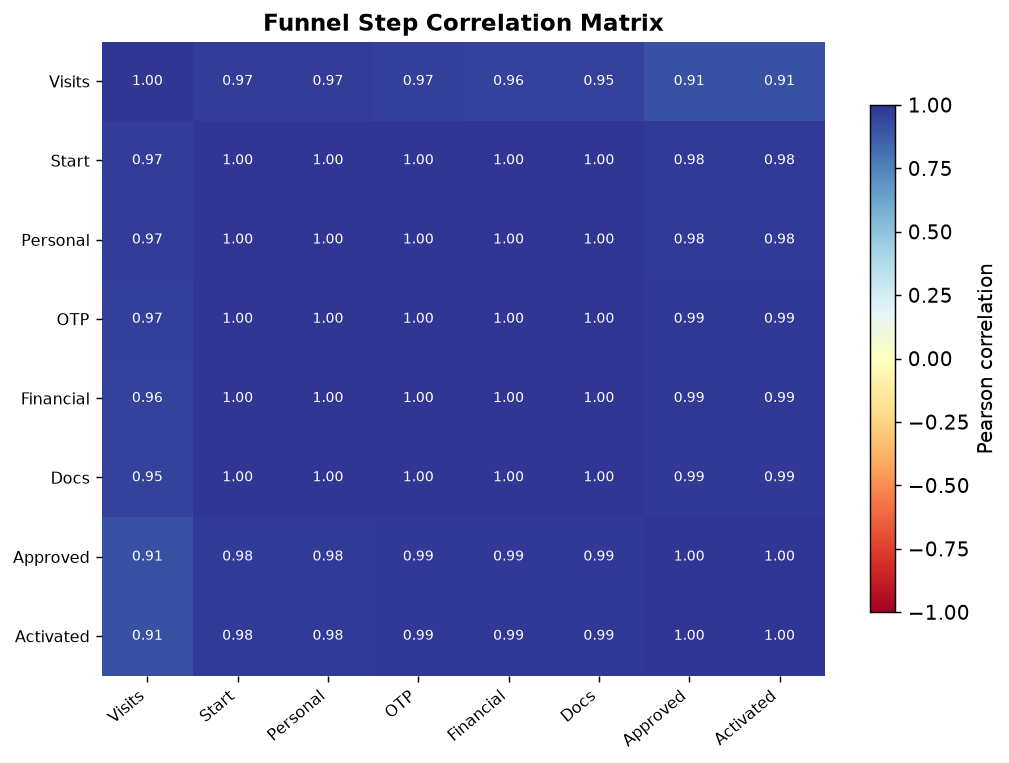

In [6]:
funnel_cols = ['visita_landing','inicio_solicitud','datos_personales','otp',
               'datos_financieros','carga_documentos','aprobacion','activacion_tarjeta']
short_labels = ['Visits','Start','Personal','OTP','Financial','Docs','Approved','Activated']

corr = df[funnel_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6), dpi=130)

# imshow renders a 2D array as a colored grid
# vmin/vmax fix the color scale to [-1, 1]
im = ax.imshow(corr, cmap='RdYlBu', vmin=-1, vmax=1, aspect='auto')

# Colorbar legend
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson correlation')

# Axis labels
ax.set_xticks(range(len(short_labels)))
ax.set_yticks(range(len(short_labels)))
ax.set_xticklabels(short_labels, rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)

# Value annotations inside each cell
for i in range(len(funnel_cols)):
    for j in range(len(funnel_cols)):
        val = corr.iloc[i, j]
        # Use white text on dark cells, dark text on light cells
        color = 'white' if abs(val) > 0.6 else '#1a1a2e'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color=color)

ax.set_title('Funnel Step Correlation Matrix', fontsize=13, fontweight='bold')
ax.spines[:].set_visible(False)   # remove all spines for heatmaps

plt.tight_layout()
plt.show()

## Summary
| Chart | When to use |
|---|---|
| Error bars | Show uncertainty around category means |
| CI band on line | Show variability around a trend |
| Scatter + regression | Quantify and visualize relationship between two metrics |
| KDE | Compare distributions smoothly across groups |
| Heatmap | Show correlations or any 2D matrix of values |

**Next:** `07_publication_quality.ipynb` — final output: DPI, fonts, export, journal style.